In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ============================================================
# PART 1: BOTTOM 30 POLICY-PRIORITY DISTRICTS
# ============================================================

df = pd.read_csv("../Data/analysis_ready.csv")

# Bottom 30 by institutional delivery rate
bottom30 = df.nsmallest(30, 'institutional_births')[
    ['State', 'District', 'institutional_births', 'female_literacy', 
     'child_marriage', 'health_insurance', 'clean_fuel']
].reset_index(drop=True)

bottom30.index = bottom30.index + 1  # rank from 1
print("=" * 90)
print("BOTTOM 30 POLICY-PRIORITY DISTRICTS — Lowest Institutional Delivery Rates")
print("=" * 90)
print(bottom30.to_string())
print(f"\nMean institutional delivery in bottom 30: {bottom30['institutional_births'].mean():.1f}%")
print(f"National mean: {df['institutional_births'].mean():.1f}%")
print(f"Gap: {df['institutional_births'].mean() - bottom30['institutional_births'].mean():.1f} percentage points")

# State-wise count in bottom 30
print("\n--- States with most districts in bottom 30 ---")
print(bottom30['State'].value_counts().to_string())


BOTTOM 30 POLICY-PRIORITY DISTRICTS — Lowest Institutional Delivery Rates
                State                 District  institutional_births  female_literacy  child_marriage  health_insurance  clean_fuel
1            Nagaland                     Mon                  21.40            78.22            2.98             39.26       13.00
2            Nagaland                    Phek                  32.20            85.82            6.53             24.93       24.19
3            Nagaland                 Kiphire                  34.77            73.69           22.54              8.76       16.44
4            Nagaland                Tuensang                  34.84            77.77           10.43             21.99       19.68
5            Nagaland               Zunheboto                  34.98            87.13            3.99             18.06       18.58
6            Nagaland                Longleng                  38.68            82.00           11.00             38.27       11.81
7 

In [3]:
# Save
bottom30.to_csv("../outputs/bottom_30_priority_districts.csv", index_label="Rank")
print("\nSaved: bottom_30_priority_districts.csv")


Saved: bottom_30_priority_districts.csv


Note: you may need to restart the kernel to use updated packages.
['DISTRICT', 'ST_NM', 'ST_CEN_CD', 'DT_CEN_CD', 'censuscode']
Saved: map_institutional_delivery.png


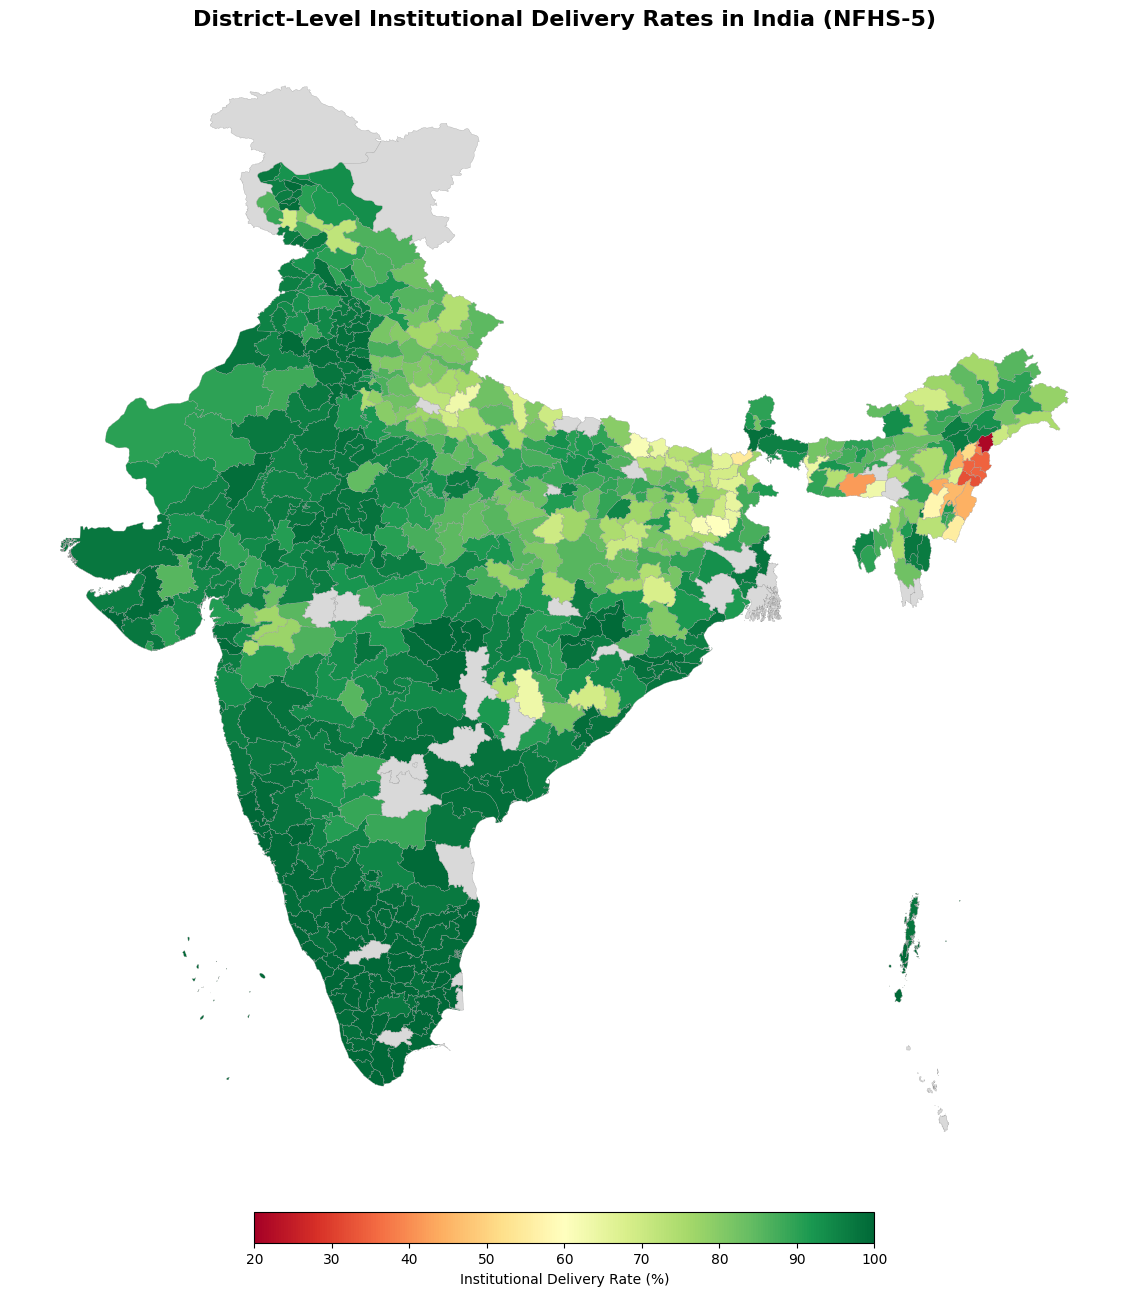

In [4]:
%pip install pyshp -q
import shapefile
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection
import numpy as np

df = pd.read_csv("../Data/analysis_ready.csv")

# Read shapefile without geopandas
sf = shapefile.Reader("../Data/india_district_shapefile/2011_Dist.shp")

# Check field names
print([field[0] for field in sf.fields[1:]])
# Find which field has district names, then update 'dist_field' below

records = sf.records()
shapes = sf.shapes()
dist_field = 0 

# Build name-to-value lookup
df['_merge'] = df['District'].str.strip().str.lower()
value_col = next(
    (c for c in ['institutional_births', 'institutional_delivery', 'institutional_delivery_rate']
     if c in df.columns),
    None
)

if value_col is None:
    raise KeyError(f"No institutional delivery column found. Available columns: {list(df.columns)}")

df['_merge'] = df['District'].astype(str).str.strip().str.lower()
df[value_col] = pd.to_numeric(df[value_col], errors='coerce')
val_map = dict(zip(df['_merge'], df[value_col]))

fig, ax = plt.subplots(1, 1, figsize=(16, 18))
patches = []
values = []

for i, (shape, rec) in enumerate(zip(shapes, records)):
    name = str(rec[dist_field]).strip().lower()
    val = val_map.get(name, np.nan)
    for part_idx in range(len(shape.parts)):
        start = shape.parts[part_idx]
        end = shape.parts[part_idx + 1] if part_idx + 1 < len(shape.parts) else len(shape.points)
        pts = shape.points[start:end]
        patches.append(Polygon(pts, closed=True))
        values.append(val)

cmap = plt.cm.RdYlGn
norm = plt.Normalize(20, 100)
colors = [cmap(norm(v)) if not np.isnan(v) else (0.85, 0.85, 0.85, 1) for v in values]

pc = PatchCollection(patches, facecolors=colors, edgecolors='0.6', linewidths=0.2)
ax.add_collection(pc)
ax.autoscale()
ax.set_aspect('equal')
ax.set_axis_off()
ax.set_title('District-Level Institutional Delivery Rates in India (NFHS-5)', fontsize=16, fontweight='bold')

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
plt.colorbar(sm, ax=ax, orientation='horizontal', shrink=0.5, pad=0.02, label='Institutional Delivery Rate (%)')
plt.savefig('../outputs/map_institutional_delivery.png', dpi=200, bbox_inches='tight', facecolor='white')
print("Saved: map_institutional_delivery.png")
plt.show()

In [5]:
import shapefile
sf = shapefile.Reader("../Data/india_district_shapefile/2011_Dist.shp")
print("Fields:", [field[0] for field in sf.fields[1:]])
print("\nFirst 5 records:")
for rec in sf.records()[:5]:
    print(list(rec))

Fields: ['DISTRICT', 'ST_NM', 'ST_CEN_CD', 'DT_CEN_CD', 'censuscode']

First 5 records:
['Adilabad', 'Andhra Pradesh', 28, 1, 532]
['Agra', 'Uttar Pradesh', 9, 15, 146]
['Ahmadabad', 'Gujarat', 24, 7, 474]
['Ahmadnagar', 'Maharashtra', 27, 26, 522]
['Aizawl', 'Mizoram', 15, 3, 283]
